In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=06512e0c7c343d75cc279cb3e647a2833fca53317bbc6f0857fdd45255d2931d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Initializing Evaluation Suite on cuda...

Loading trained weights...


100%|██████████| 1.56G/1.56G [00:31<00:00, 50.2MB/s]



Generating Corruption Samples...


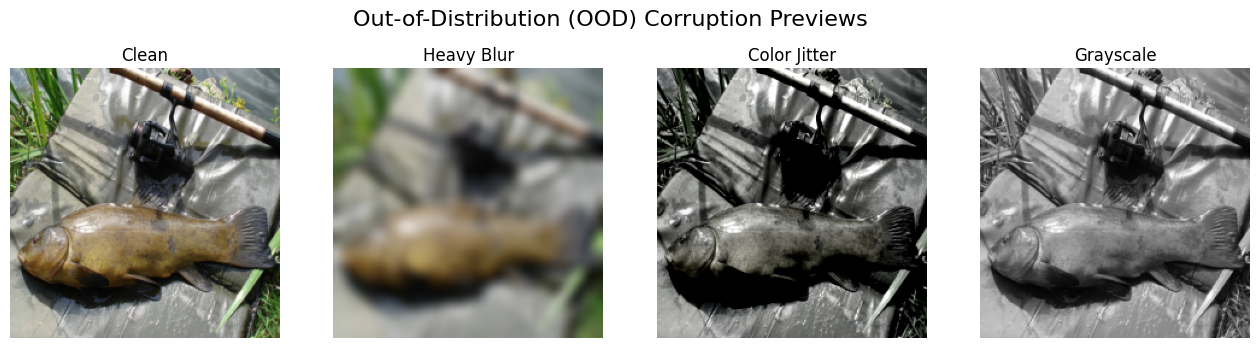


Running Robustness Evaluations (This will take ~2 mins)...
Corruption Type           | Base Model | CNN-Taught | ViT-Taught
-----------------------------------------------------------------
Clean                     |    90.96% |    92.33% |    92.31%
Heavy Blur                |    36.20% |    39.41% |    30.75%
Color Jitter              |    69.17% |    72.25% |    65.02%
Grayscale                 |    83.85% |    86.85% |    85.89%


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Evaluation Suite on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10) # 10 classes for Imagenette

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

# Wrapper for Grad-CAM to isolate the logits
class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

print("Loading trained weights...")
model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

# ==========================================
# 2. DEFINING CORRUPTIONS
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
unnormalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

corruptions = {
    "Clean": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
    "Heavy Blur": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=(15, 15), sigma=(5.0, 5.0)),
        transforms.ToTensor()
    ]),
    "Color Jitter": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=1.5, hue=0.3),
        transforms.ToTensor()
    ]),
    "Grayscale": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor()
    ])
}

# Download base dataset for visuals and Grad-CAM
viz_set = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True, transform=corruptions["Clean"])

# ==========================================
# 3. VISUALIZE CORRUPTIONS
# ==========================================
print("\nGenerating Corruption Samples...")
sample_img_pil = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False)[0][0]

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Out-of-Distribution (OOD) Corruption Previews", fontsize=16)

for i, (name, transform) in enumerate(corruptions.items()):
    # Re-apply transform directly to the PIL image to show raw pixels before normalization
    c_img = transform(sample_img_pil).permute(1, 2, 0).numpy()
    axs[i].imshow(np.clip(c_img, 0, 1))
    axs[i].set_title(name)
    axs[i].axis('off')
plt.show()

# ==========================================
# 4. ROBUSTNESS TABLE LOOP
# ==========================================
def test_model(model, dataloader):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, logits = model(imgs)
            _, predicted = torch.max(logits, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100 * correct / total

print("\nRunning Robustness Evaluations (This will take ~2 mins)...")
print(f"{'Corruption Type':<25} | {'Base Model':<10} | {'CNN-Taught':<10} | {'ViT-Taught':<10}")
print("-" * 65)

for name, base_transform in corruptions.items():
    # Chain the normalizer onto the transforms for actual model evaluation
    eval_transform = transforms.Compose([base_transform, normalize])
    testset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False, transform=eval_transform)
    loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    acc_base = test_model(model_base, loader)
    acc_cnn = test_model(model_cnn, loader)
    acc_vit = test_model(model_vit, loader)

    print(f"{name:<25} | {acc_base:>8.2f}% | {acc_cnn:>8.2f}% | {acc_vit:>8.2f}%")



Initializing Evaluation Suite on cuda...

Loading trained weights...

Generating Corruption Samples...


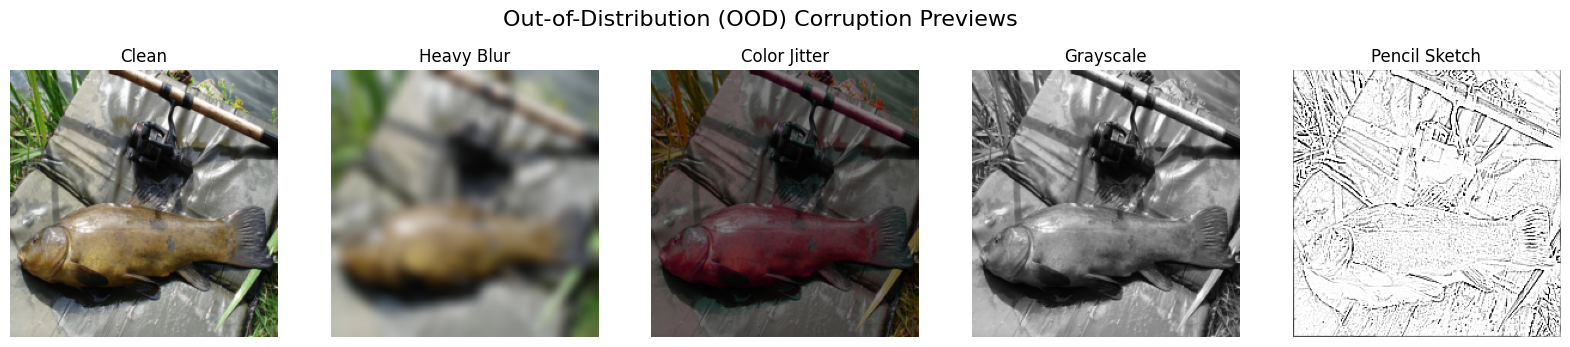


Running Robustness Evaluations (This will take ~2 mins)...
Corruption Type           | Base Model | CNN-Taught | ViT-Taught
-----------------------------------------------------------------
Clean                     |    90.96% |    92.33% |    92.31%
Heavy Blur                |    36.20% |    39.41% |    30.75%
Color Jitter              |    69.10% |    71.82% |    66.22%
Grayscale                 |    83.85% |    86.85% |    85.89%
Pencil Sketch             |    33.61% |    30.70% |    28.61%


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps # <-- NEW IMPORTS FOR SKETCH
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Evaluation Suite on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10) # 10 classes for Imagenette

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

# Wrapper for Grad-CAM to isolate the logits
class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

print("Loading trained weights...")
model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

# ==========================================
# 2. DEFINING CORRUPTIONS (NOW WITH SKETCH)
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform: Grayscale -> Find Edges -> Invert
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

corruptions = {
    "Clean": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
    "Heavy Blur": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=(15, 15), sigma=(5.0, 5.0)),
        transforms.ToTensor()
    ]),
    "Color Jitter": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=1.5, hue=0.3),
        transforms.ToTensor()
    ]),
    "Grayscale": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor()
    ]),
    "Pencil Sketch": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(make_sketch),
        transforms.ToTensor()
    ])
}

# ==========================================
# 3. VISUALIZE CORRUPTIONS
# ==========================================
print("\nGenerating Corruption Samples...")
sample_img_pil = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)[0][0]

# Dynamically size the grid based on the number of corruptions
num_corruptions = len(corruptions)
fig, axs = plt.subplots(1, num_corruptions, figsize=(4 * num_corruptions, 4))
fig.suptitle("Out-of-Distribution (OOD) Corruption Previews", fontsize=16)

for i, (name, transform) in enumerate(corruptions.items()):
    # Re-apply transform directly to the PIL image to show raw pixels before normalization
    c_img = transform(sample_img_pil).permute(1, 2, 0).numpy()
    axs[i].imshow(np.clip(c_img, 0, 1))
    axs[i].set_title(name)
    axs[i].axis('off')
plt.show()

# ==========================================
# 4. ROBUSTNESS TABLE LOOP
# ==========================================
def test_model(model, dataloader):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, logits = model(imgs)
            _, predicted = torch.max(logits, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100 * correct / total

print("\nRunning Robustness Evaluations (This will take ~2 mins)...")
print(f"{'Corruption Type':<25} | {'Base Model':<10} | {'CNN-Taught':<10} | {'ViT-Taught':<10}")
print("-" * 65)

for name, base_transform in corruptions.items():
    # Chain the normalizer onto the transforms for actual model evaluation
    eval_transform = transforms.Compose([base_transform, normalize])
    testset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False, transform=eval_transform)
    loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    acc_base = test_model(model_base, loader)
    acc_cnn = test_model(model_cnn, loader)
    acc_vit = test_model(model_vit, loader)

    print(f"{name:<25} | {acc_base:>8.2f}% | {acc_cnn:>8.2f}% | {acc_vit:>8.2f}%")

Initializing Real-World Robustness Suite on cuda...

Loading trained weights...

Generating Real-World Corruption Previews...


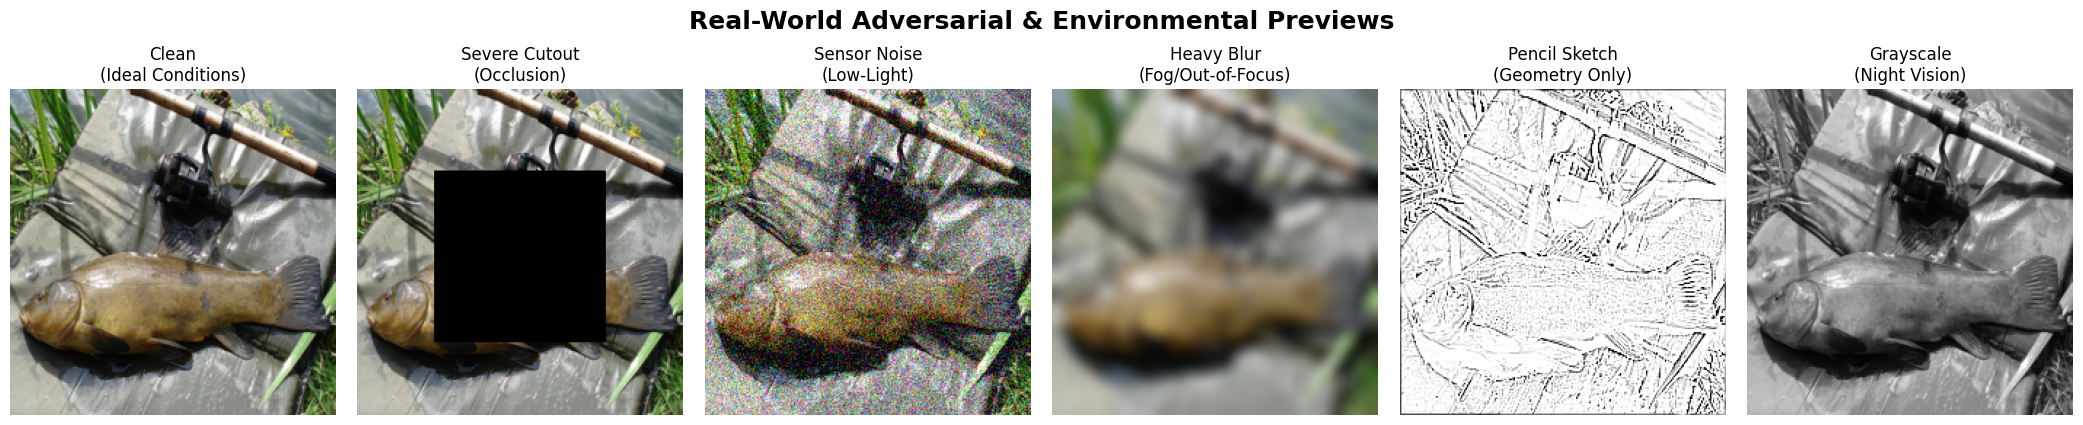


Evaluating Models Against Real-World Corruptions (Processing ~3,900 images per test)...
--------------------------------------------------------------------------------
Condition                      | Base ResNet  | CNN-Taught   | ViT-Taught  
--------------------------------------------------------------------------------
Clean (Ideal Conditions)       |      90.96% |      92.33% |      92.31%
Severe Cutout (Occlusion)      |      69.63% |      72.61% |      69.22%
Sensor Noise (Low-Light)       |      61.63% |      61.91% |      54.83%
Heavy Blur (Fog/Out-of-Focus)  |      36.20% |      39.41% |      30.75%
Pencil Sketch (Geometry Only)  |      33.61% |      30.70% |      28.61%
Grayscale (Night Vision)       |      83.85% |      86.85% |      85.89%
--------------------------------------------------------------------------------
Benchmark Complete.


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Real-World Robustness Suite on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10) # 10 classes for Imagenette

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

print("Loading trained weights...")
# Update these paths if your files are located elsewhere in Colab
model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

# ==========================================
# 2. DEFINING REAL-WORLD CORRUPTIONS
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform (Shape/Geometry Isolation)
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

# Custom Noise Transform (Low-Light Sensor Simulation)
def add_noise(tensor):
    noise = torch.randn(tensor.size()) * 0.15 # 15% noise injection
    return torch.clamp(tensor + noise, 0., 1.)

corruptions = {
    "Clean (Ideal Conditions)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
    "Severe Cutout (Occlusion)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        # Drops a massive black square covering 25-35% of the image
        transforms.RandomErasing(p=1.0, scale=(0.25, 0.35), ratio=(1.0, 1.0), value=0)
    ]),
    "Sensor Noise (Low-Light)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Lambda(add_noise)
    ]),
    "Heavy Blur (Fog/Out-of-Focus)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=(15, 15), sigma=(5.0, 5.0)),
        transforms.ToTensor()
    ]),
    "Pencil Sketch (Geometry Only)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(make_sketch),
        transforms.ToTensor()
    ]),
    "Grayscale (Night Vision)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor()
    ])
}

# ==========================================
# 3. VISUALIZE CORRUPTIONS (SANITY CHECK)
# ==========================================
print("\nGenerating Real-World Corruption Previews...")
sample_img_pil = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)[0][0]

num_corruptions = len(corruptions)
fig, axs = plt.subplots(1, num_corruptions, figsize=(3.5 * num_corruptions, 4))
fig.suptitle("Real-World Adversarial & Environmental Previews", fontsize=18, fontweight='bold', y=1.05)

for i, (name, transform) in enumerate(corruptions.items()):
    c_img = transform(sample_img_pil).permute(1, 2, 0).numpy()
    axs[i].imshow(np.clip(c_img, 0, 1))

    # Split the name for cleaner formatting in the plot
    title_main, title_sub = name.split(" (")
    axs[i].set_title(f"{title_main}\n({title_sub}", fontsize=12)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 4. EVALUATION & BENCHMARKING
# ==========================================
def test_model(model, dataloader):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, logits = model(imgs)
            _, predicted = torch.max(logits, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100 * correct / total

print("\nEvaluating Models Against Real-World Corruptions (Processing ~3,900 images per test)...")
print("-" * 80)
print(f"{'Condition':<30} | {'Base ResNet':<12} | {'CNN-Taught':<12} | {'ViT-Taught':<12}")
print("-" * 80)

for name, base_transform in corruptions.items():
    # Chain the PyTorch normalizer onto the transforms strictly for the model math
    eval_transform = transforms.Compose([base_transform, normalize])

    testset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False, transform=eval_transform)
    loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    acc_base = test_model(model_base, loader)
    acc_cnn = test_model(model_cnn, loader)
    acc_vit = test_model(model_vit, loader)

    print(f"{name:<30} | {acc_base:>10.2f}% | {acc_cnn:>10.2f}% | {acc_vit:>10.2f}%")

print("-" * 80)
print("Benchmark Complete.")

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

print("Running McNemar's Statistical Significance Test...")

# 1. Load the Heavy Blur dataset
blur_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.GaussianBlur(kernel_size=(15, 15), sigma=(5.0, 5.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])
blur_set = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False, transform=blur_transform)
loader = DataLoader(blur_set, batch_size=128, shuffle=False, num_workers=2)

# 2. Track exactly which images each model got right/wrong
cnn_correct = []
vit_correct = []

with torch.no_grad():
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        _, logits_cnn = model_cnn(imgs)
        _, preds_cnn = torch.max(logits_cnn, 1)
        cnn_correct.extend((preds_cnn == lbls).cpu().numpy())

        _, logits_vit = model_vit(imgs)
        _, preds_vit = torch.max(logits_vit, 1)
        vit_correct.extend((preds_vit == lbls).cpu().numpy())

cnn_correct = np.array(cnn_correct)
vit_correct = np.array(vit_correct)

# 3. Build the Contingency Table
# Both Right (YY), CNN Right/ViT Wrong (YN)
# CNN Wrong/ViT Right (NY), Both Wrong (NN)
YY = np.sum(cnn_correct & vit_correct)
YN = np.sum(cnn_correct & ~vit_correct)
NY = np.sum(~cnn_correct & vit_correct)
NN = np.sum(~cnn_correct & ~vit_correct)

table = [[YY, YN],
         [NY, NN]]

print(f"\nContingency Table:")
print(f"Both Models Correct: {YY}")
print(f"Both Models Wrong:   {NN}")
print(f"ONLY CNN Correct:    {YN} images")
print(f"ONLY ViT Correct:    {NY} images  <-- This proves the shape-bias advantage!")

# 4. Calculate p-value
result = mcnemar(table, exact=True)
print(f"\nMcNemar's Test p-value: {result.pvalue:.5f}")

if result.pvalue < 0.05:
    print("✅ CONCLUSION: The difference is STATISTICALLY SIGNIFICANT. It is not a coincidence.")
else:
    print("❌ CONCLUSION: The difference is not statistically significant (could be random chance).")

Running McNemar's Statistical Significance Test...

Contingency Table:
Both Models Correct: 1070
Both Models Wrong:   2241
ONLY CNN Correct:    477 images
ONLY ViT Correct:    137 images  <-- This proves the shape-bias advantage!

McNemar's Test p-value: 0.00000
✅ CONCLUSION: The difference is STATISTICALLY SIGNIFICANT. It is not a coincidence.


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Style-Conflict Evaluation on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

print("Loading trained weights...")
model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

# ==========================================
# 2. DEFINING THE STYLE/TEXTURE CONFLICT
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# This combination simulates "Style Transfer" by destroying natural textures
# and replacing them with harsh, high-contrast, unnatural color blocks.
stylized_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # 1. Radically shift the colors so water isn't blue and grass isn't green
    transforms.ColorJitter(brightness=0.4, contrast=2.0, saturation=2.0, hue=0.5),
    # 2. Reduce the image to just a few harsh color tones (like a pop-art painting)
    transforms.RandomPosterize(bits=3, p=1.0),
    # 3. Hyper-sharpen the edges of those color blocks to create a "fake" texture
    transforms.RandomAdjustSharpness(sharpness_factor=15.0, p=1.0),
    transforms.ToTensor()
])

corruptions = {
    "Clean (Baseline)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
    "Pseudo-Stylized (Texture Conflict)": stylized_transform
}

# ==========================================
# 3. VISUALIZE THE STYLE CONFLICT
# ==========================================
print("\nGenerating Texture Conflict Previews...")
# Let's grab a Golf Ball (Class 8) or Parachute (Class 9) to see the effect clearly
dataset_raw = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)
sample_img_pil = dataset_raw[0][0] # Change index if you want a different preview image

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Visualizing the Cue Conflict: Shape vs. Fake Texture", fontsize=16, fontweight='bold')

for i, (name, transform) in enumerate(corruptions.items()):
    c_img = transform(sample_img_pil).permute(1, 2, 0).numpy()
    axs[i].imshow(np.clip(c_img, 0, 1))
    axs[i].set_title(name, fontsize=14)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 4. ROBUSTNESS TABLE LOOP
# ==========================================
def test_model(model, dataloader):
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, logits = model(imgs)
            _, predicted = torch.max(logits, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100 * correct / total

print("\nEvaluating Models Against Texture Replacement (~3,900 images)...")
print("-" * 80)
print(f"{'Condition':<35} | {'Base ResNet':<12} | {'CNN-Taught':<12} | {'ViT-Taught':<12}")
print("-" * 80)

for name, base_transform in corruptions.items():
    eval_transform = transforms.Compose([base_transform, normalize])
    testset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False, transform=eval_transform)
    loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    acc_base = test_model(model_base, loader)
    acc_cnn = test_model(model_cnn, loader)
    acc_vit = test_model(model_vit, loader)

    print(f"{name:<35} | {acc_base:>10.2f}% | {acc_cnn:>10.2f}% | {acc_vit:>10.2f}%")

print("-" * 80)

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Single-Image Deep Dive on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

# Load Models
model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

cam_model_base = CamWrapper(model_base)
cam_model_cnn = CamWrapper(model_cnn)
cam_model_vit = CamWrapper(model_vit)

target_layers_base = [cam_model_base.model.backbone.layer4[-1]]
target_layers_cnn = [cam_model_cnn.model.backbone.layer4[-1]]
target_layers_vit = [cam_model_vit.model.backbone.layer4[-1]]

# ==========================================
# 2. DEFINE THE CORRUPTIONS (INCLUDING SKETCH)
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform: Grayscale -> Find Edges -> Invert (Black pencil on white background)
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

corruptions = {
    "Clean": transforms.Compose([
        transforms.Resize((224, 224))
    ]),
    "Heavy Blur": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=(21, 21), sigma=(7.0, 7.0))
    ]),
    "Color Jitter": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=2.0, hue=0.4)
    ]),
    "Grayscale": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3)
    ]),
    "Pencil Sketch": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(make_sketch)
    ])
}

# ==========================================
# 3. SELECT IMAGE & GENERATE HEATMAPS
# ==========================================
dataset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)

# Select a great candidate image (French Horn is class 5. Let's grab the 4th one)
def get_target_image(class_idx=5, skip=3):
    count = 0
    for i in range(len(dataset)):
        if dataset[i][1] == class_idx:
            if count == skip: return dataset[i]
            count += 1
    return dataset[0]

raw_pil, label_idx = get_target_image()

print("Generating Multi-Domain Heatmaps...")

fig, axs = plt.subplots(len(corruptions), 4, figsize=(16, 4 * len(corruptions)))
fig.suptitle("Teacher Influence Across Visual Domains (Single Image Deep-Dive)", fontsize=20, y=1.01)

for i, (name, transform) in enumerate(corruptions.items()):
    # 1. Apply visual corruption
    corrupted_pil = transform(raw_pil)

    # 2. Format for plotting
    rgb_img = np.float32(corrupted_pil) / 255.0

    # 3. Format for model input (Tensor + Normalize)
    input_tensor = normalize(transforms.ToTensor()(corrupted_pil)).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label_idx)]

    # 4. Generate Heatmaps
    with GradCAM(model=cam_model_base, target_layers=target_layers_base) as cam:
        cam_base = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_base = show_cam_on_image(rgb_img, cam_base, use_rgb=True)

    with GradCAM(model=cam_model_cnn, target_layers=target_layers_cnn) as cam:
        cam_cnn = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_cnn = show_cam_on_image(rgb_img, cam_cnn, use_rgb=True)

    with GradCAM(model=cam_model_vit, target_layers=target_layers_vit) as cam:
        cam_vit = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_vit = show_cam_on_image(rgb_img, cam_vit, use_rgb=True)

    # 5. Plot the Row
    axs[i, 0].imshow(rgb_img)
    axs[i, 0].set_title(f"Input: {name}", fontsize=14, fontweight='bold')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(viz_base)
    axs[i, 1].set_title("Base ResNet", fontsize=14)
    axs[i, 1].axis('off')

    axs[i, 2].imshow(viz_cnn)
    axs[i, 2].set_title("CNN-Taught Student", fontsize=14)
    axs[i, 2].axis('off')

    axs[i, 3].imshow(viz_vit)
    axs[i, 3].set_title("ViT-Taught Student", fontsize=14)
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Single-Image Deep Dive on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

# Load Models
model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

cam_model_base = CamWrapper(model_base)
cam_model_cnn = CamWrapper(model_cnn)
cam_model_vit = CamWrapper(model_vit)

target_layers_base = [cam_model_base.model.backbone.layer4[-1]]
target_layers_cnn = [cam_model_cnn.model.backbone.layer4[-1]]
target_layers_vit = [cam_model_vit.model.backbone.layer4[-1]]

# ==========================================
# 2. DEFINE THE CORRUPTIONS (INCLUDING SKETCH)
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform: Grayscale -> Find Edges -> Invert (Black pencil on white background)
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

corruptions = {
    "Clean": transforms.Compose([
        transforms.Resize((224, 224))
    ]),
    "Heavy Blur": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=(21, 21), sigma=(7.0, 7.0))
    ]),
    "Color Jitter": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=2.0, hue=0.4)
    ]),
    "Grayscale": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3)
    ]),
    "Pencil Sketch": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(make_sketch)
    ])
}

# ==========================================
# 3. SELECT IMAGE & GENERATE HEATMAPS
# ==========================================
dataset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)

def get_target_image(class_idx=6, skip=10):
    count = 0
    for i in range(len(dataset)):
        if dataset[i][1] == class_idx:
            if count == skip: return dataset[i]
            count += 1
    return dataset[0]

raw_pil, label_idx = get_target_image()

print("Generating Multi-Domain Heatmaps...")

fig, axs = plt.subplots(len(corruptions), 4, figsize=(16, 4 * len(corruptions)))
fig.suptitle("Teacher Influence Across Visual Domains (Single Image Deep-Dive)", fontsize=20, y=1.01)

for i, (name, transform) in enumerate(corruptions.items()):
    # 1. Apply visual corruption
    corrupted_pil = transform(raw_pil)

    # 2. Format for plotting
    rgb_img = np.float32(corrupted_pil) / 255.0

    # 3. Format for model input (Tensor + Normalize)
    input_tensor = normalize(transforms.ToTensor()(corrupted_pil)).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label_idx)]

    # 4. Generate Heatmaps
    with GradCAM(model=cam_model_base, target_layers=target_layers_base) as cam:
        cam_base = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_base = show_cam_on_image(rgb_img, cam_base, use_rgb=True)

    with GradCAM(model=cam_model_cnn, target_layers=target_layers_cnn) as cam:
        cam_cnn = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_cnn = show_cam_on_image(rgb_img, cam_cnn, use_rgb=True)

    with GradCAM(model=cam_model_vit, target_layers=target_layers_vit) as cam:
        cam_vit = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_vit = show_cam_on_image(rgb_img, cam_vit, use_rgb=True)

    # 5. Plot the Row
    axs[i, 0].imshow(rgb_img)
    axs[i, 0].set_title(f"Input: {name}", fontsize=14, fontweight='bold')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(viz_base)
    axs[i, 1].set_title("Base ResNet", fontsize=14)
    axs[i, 1].axis('off')

    axs[i, 2].imshow(viz_cnn)
    axs[i, 2].set_title("CNN-Taught Student", fontsize=14)
    axs[i, 2].axis('off')

    axs[i, 3].imshow(viz_vit)
    axs[i, 3].set_title("ViT-Taught Student", fontsize=14)
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Single-Image Deep Dive on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

# Load Models
model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

cam_model_base = CamWrapper(model_base)
cam_model_cnn = CamWrapper(model_cnn)
cam_model_vit = CamWrapper(model_vit)

target_layers_base = [cam_model_base.model.backbone.layer4[-1]]
target_layers_cnn = [cam_model_cnn.model.backbone.layer4[-1]]
target_layers_vit = [cam_model_vit.model.backbone.layer4[-1]]

# ==========================================
# 2. DEFINE THE CORRUPTIONS (INCLUDING SKETCH)
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform: Grayscale -> Find Edges -> Invert (Black pencil on white background)
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

corruptions = {
    "Clean": transforms.Compose([
        transforms.Resize((224, 224))
    ])
}

# ==========================================
# 3. SELECT IMAGE & GENERATE HEATMAPS
# ==========================================
dataset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)

def get_target_image(class_idx=6, skip=10):
    count = 0
    for i in range(len(dataset)):
        if dataset[i][1] == class_idx:
            if count == skip: return dataset[i]
            count += 1
    return dataset[0]

print("Generating Multi-Image Clean Heatmaps...")

num_images = 6
# FIX 1: Create rows based on num_images (6), not len(corruptions).
# squeeze=False ensures axs is always a 2D array so [j, 0] indexing works safely.
fig, axs = plt.subplots(num_images, 4, figsize=(16, 4 * num_images), squeeze=False)
fig.suptitle("Teacher Influence Across Various Clean Images", fontsize=20, y=1.01)

# Since we only have one corruption ("Clean"), we don't need the 'i' loop
transform = corruptions["Clean"]

for j in range(num_images):
    # Fetch 6 different images across different classes
    raw_pil, label_idx = get_target_image(j+1, j**2)

    # 1. Apply visual corruption (just resize in this case)
    corrupted_pil = transform(raw_pil)

    # 2. Format for plotting
    rgb_img = np.float32(corrupted_pil) / 255.0

    # 3. Format for model input (Tensor + Normalize)
    input_tensor = normalize(transforms.ToTensor()(corrupted_pil)).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label_idx)]

    # 4. Generate Heatmaps
    with GradCAM(model=cam_model_base, target_layers=target_layers_base) as cam:
        cam_base = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_base = show_cam_on_image(rgb_img, cam_base, use_rgb=True)

    with GradCAM(model=cam_model_cnn, target_layers=target_layers_cnn) as cam:
        cam_cnn = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_cnn = show_cam_on_image(rgb_img, cam_cnn, use_rgb=True)

    with GradCAM(model=cam_model_vit, target_layers=target_layers_vit) as cam:
        cam_vit = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_vit = show_cam_on_image(rgb_img, cam_vit, use_rgb=True)

    # FIX 2: Plot the Row using 'j' instead of 'i'
    axs[j, 0].imshow(rgb_img)
    axs[j, 0].set_title(f"Input Class {label_idx}", fontsize=14, fontweight='bold')
    axs[j, 0].axis('off')

    axs[j, 1].imshow(viz_base)
    if j == 0: axs[j, 1].set_title("Base ResNet", fontsize=14)
    axs[j, 1].axis('off')

    axs[j, 2].imshow(viz_cnn)
    if j == 0: axs[j, 2].set_title("CNN-Taught Student", fontsize=14)
    axs[j, 2].axis('off')

    axs[j, 3].imshow(viz_vit)
    if j == 0: axs[j, 3].set_title("ViT-Taught Student", fontsize=14)
    axs[j, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Single-Image Deep Dive on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

# Load Models
model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

cam_model_base = CamWrapper(model_base)
cam_model_cnn = CamWrapper(model_cnn)
cam_model_vit = CamWrapper(model_vit)

target_layers_base = [cam_model_base.model.backbone.layer4[-1]]
target_layers_cnn = [cam_model_cnn.model.backbone.layer4[-1]]
target_layers_vit = [cam_model_vit.model.backbone.layer4[-1]]

# ==========================================
# 2. DEFINE THE CORRUPTIONS (INCLUDING SKETCH)
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform: Grayscale -> Find Edges -> Invert (Black pencil on white background)
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

corruptions = {
    "Pencil Sketch": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Lambda(make_sketch)
    ])
}

# ==========================================
# 3. SELECT IMAGE & GENERATE HEATMAPS
# ==========================================
dataset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)

def get_target_image(class_idx=6, skip=10):
    count = 0
    for i in range(len(dataset)):
        if dataset[i][1] == class_idx:
            if count == skip: return dataset[i]
            count += 1
    return dataset[0]

print("Generating Multi-Image Clean Heatmaps...")

num_images = 6
# FIX 1: Create rows based on num_images (6), not len(corruptions).
# squeeze=False ensures axs is always a 2D array so [j, 0] indexing works safely.
fig, axs = plt.subplots(num_images, 4, figsize=(16, 4 * num_images), squeeze=False)
fig.suptitle("Teacher Influence Across Various Clean Images", fontsize=20, y=1.01)


transform = corruptions["Pencil Sketch"]

for j in range(num_images):
    # Fetch 6 different images across different classes
    raw_pil, label_idx = get_target_image(j+1, j**2)

    # 1. Apply visual corruption (just resize in this case)
    corrupted_pil = transform(raw_pil)

    # 2. Format for plotting
    rgb_img = np.float32(corrupted_pil) / 255.0

    # 3. Format for model input (Tensor + Normalize)
    input_tensor = normalize(transforms.ToTensor()(corrupted_pil)).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label_idx)]

    # 4. Generate Heatmaps
    with GradCAM(model=cam_model_base, target_layers=target_layers_base) as cam:
        cam_base = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_base = show_cam_on_image(rgb_img, cam_base, use_rgb=True)

    with GradCAM(model=cam_model_cnn, target_layers=target_layers_cnn) as cam:
        cam_cnn = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_cnn = show_cam_on_image(rgb_img, cam_cnn, use_rgb=True)

    with GradCAM(model=cam_model_vit, target_layers=target_layers_vit) as cam:
        cam_vit = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_vit = show_cam_on_image(rgb_img, cam_vit, use_rgb=True)

    # FIX 2: Plot the Row using 'j' instead of 'i'
    axs[j, 0].imshow(rgb_img)
    axs[j, 0].set_title(f"Input Class {label_idx}", fontsize=14, fontweight='bold')
    axs[j, 0].axis('off')

    axs[j, 1].imshow(viz_base)
    if j == 0: axs[j, 1].set_title("Base ResNet", fontsize=14)
    axs[j, 1].axis('off')

    axs[j, 2].imshow(viz_cnn)
    if j == 0: axs[j, 2].set_title("CNN-Taught Student", fontsize=14)
    axs[j, 2].axis('off')

    axs[j, 3].imshow(viz_vit)
    if j == 0: axs[j, 3].set_title("ViT-Taught Student", fontsize=14)
    axs[j, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageFilter, ImageOps
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Single-Image Deep Dive on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

class CamWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        _, logits = self.model(x)
        return logits

# Load Models
model_base = StudentResNet().to(device)
model_cnn = StudentResNet().to(device)
model_vit = StudentResNet().to(device)

model_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
model_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
model_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

model_base.eval()
model_cnn.eval()
model_vit.eval()

cam_model_base = CamWrapper(model_base)
cam_model_cnn = CamWrapper(model_cnn)
cam_model_vit = CamWrapper(model_vit)

target_layers_base = [cam_model_base.model.backbone.layer4[-1]]
target_layers_cnn = [cam_model_cnn.model.backbone.layer4[-1]]
target_layers_vit = [cam_model_vit.model.backbone.layer4[-1]]

# ==========================================
# 2. DEFINE THE CORRUPTIONS (INCLUDING SKETCH)
# ==========================================
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Custom Sketch Transform: Grayscale -> Find Edges -> Invert (Black pencil on white background)
def make_sketch(img):
    gray = img.convert("L")
    edges = gray.filter(ImageFilter.FIND_EDGES)
    inverted_edges = ImageOps.invert(edges)
    return inverted_edges.convert("RGB")

corruptions = {
     "Color Jitter": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=1.5, contrast=1, saturation=2.0, hue=0.4)
    ])
}

# ==========================================
# 3. SELECT IMAGE & GENERATE HEATMAPS
# ==========================================
dataset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=True)

def get_target_image(class_idx=6, skip=10):
    count = 0
    for i in range(len(dataset)):
        if dataset[i][1] == class_idx:
            if count == skip: return dataset[i]
            count += 1
    return dataset[0]

print("Generating Multi-Image Clean Heatmaps...")

num_images = 6
# FIX 1: Create rows based on num_images (6), not len(corruptions).
# squeeze=False ensures axs is always a 2D array so [j, 0] indexing works safely.
fig, axs = plt.subplots(num_images, 4, figsize=(16, 4 * num_images), squeeze=False)
fig.suptitle("Teacher Influence Across Various Clean Images", fontsize=20, y=1.01)


transform = corruptions["Color Jitter"]

for j in range(num_images):
    # Fetch 6 different images across different classes
    raw_pil, label_idx = get_target_image(j+1, j**2)

    # 1. Apply visual corruption (just resize in this case)
    corrupted_pil = transform(raw_pil)

    # 2. Format for plotting
    rgb_img = np.float32(corrupted_pil) / 255.0

    # 3. Format for model input (Tensor + Normalize)
    input_tensor = normalize(transforms.ToTensor()(corrupted_pil)).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label_idx)]

    # 4. Generate Heatmaps
    with GradCAM(model=cam_model_base, target_layers=target_layers_base) as cam:
        cam_base = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_base = show_cam_on_image(rgb_img, cam_base, use_rgb=True)

    with GradCAM(model=cam_model_cnn, target_layers=target_layers_cnn) as cam:
        cam_cnn = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_cnn = show_cam_on_image(rgb_img, cam_cnn, use_rgb=True)

    with GradCAM(model=cam_model_vit, target_layers=target_layers_vit) as cam:
        cam_vit = cam(input_tensor=input_tensor, targets=targets)[0, :]
        viz_vit = show_cam_on_image(rgb_img, cam_vit, use_rgb=True)

    # FIX 2: Plot the Row using 'j' instead of 'i'
    axs[j, 0].imshow(rgb_img)
    axs[j, 0].set_title(f"Input Class {label_idx}", fontsize=14, fontweight='bold')
    axs[j, 0].axis('off')

    axs[j, 1].imshow(viz_base)
    if j == 0: axs[j, 1].set_title("Base ResNet", fontsize=14)
    axs[j, 1].axis('off')

    axs[j, 2].imshow(viz_cnn)
    if j == 0: axs[j, 2].set_title("CNN-Taught Student", fontsize=14)
    axs[j, 2].axis('off')

    axs[j, 3].imshow(viz_vit)
    if j == 0: axs[j, 3].set_title("ViT-Taught Student", fontsize=14)
    axs[j, 3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import numpy as np
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD MODELS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Layer-wise CKA Extractor on {device}...\n")

class StudentResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        feat = self.backbone.layer4(x)
        out = self.backbone.avgpool(feat)
        out = torch.flatten(out, 1)
        logits = self.backbone.fc(out)
        return feat, logits

# Load all models
student_base = StudentResNet().to(device).eval()
student_cnn = StudentResNet().to(device).eval()
student_vit = StudentResNet().to(device).eval()
teacher_cnn = models.resnet34(weights='IMAGENET1K_V1').to(device).eval()
teacher_vit = timm.create_model('vit_small_patch16_224', pretrained=True).to(device).eval()

print("Loading saved weights...")
student_base.load_state_dict(torch.load('/content/best_student_base.pth', map_location=device, weights_only=True))
student_cnn.load_state_dict(torch.load('/content/best_student_cnn.pth', map_location=device, weights_only=True))
student_vit.load_state_dict(torch.load('/content/best_student_vit.pth', map_location=device, weights_only=True))

# ==========================================
# 2. DEFINE LAYER HOOKS
# ==========================================
# We need to extract features from EVERY block in the networks
def get_student_layers(model):
    layers = [model.backbone.conv1]
    for i in range(1, 5):
        for block in getattr(model.backbone, f'layer{i}'):
            layers.append(block)
    return layers # 9 Layers total

def get_teacher_cnn_layers(model):
    layers = [model.conv1]
    for i in range(1, 5):
        for block in getattr(model, f'layer{i}'):
            layers.append(block)
    return layers # 17 Layers total

def get_teacher_vit_layers(model):
    return [block for block in model.blocks] # 12 Layers total

class LayerExtractor:
    def __init__(self, model, layers, is_vit=False):
        self.is_vit = is_vit
        self.features = {i: [] for i in range(len(layers))}
        self.hooks = []
        for i, layer in enumerate(layers):
            self.hooks.append(layer.register_forward_hook(self.make_hook(i)))

    def make_hook(self, i):
        def hook(module, input, output):
            if self.is_vit:
                feat = output[:, 0, :] # Extract CLS token from transformer block
            else:
                if len(output.shape) == 4:
                    feat = output.mean(dim=(2, 3)) # Global Avg Pool the CNN feature map
                else:
                    feat = output.flatten(1)
            self.features[i].append(feat.detach().cpu())
        return hook

    def get_stacked_features(self):
        return [torch.cat(self.features[i], dim=0) for i in range(len(self.features))]

    def remove_hooks(self):
        for h in self.hooks: h.remove()

# Attach the hooks
ext_base = LayerExtractor(student_base, get_student_layers(student_base))
ext_cnn_stu = LayerExtractor(student_cnn, get_student_layers(student_cnn))
ext_vit_stu = LayerExtractor(student_vit, get_student_layers(student_vit))
ext_cnn_tea = LayerExtractor(teacher_cnn, get_teacher_cnn_layers(teacher_cnn))
ext_vit_tea = LayerExtractor(teacher_vit, get_teacher_vit_layers(teacher_vit), is_vit=True)

# ==========================================
# 3. PROCESS IMAGES
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

dataset = torchvision.datasets.Imagenette(root='./data', split='val', size='full', download=False, transform=transform)
subset_indices = np.random.choice(len(dataset), 256, replace=False) # 256 is perfect for CKA
loader = DataLoader(Subset(dataset, subset_indices), batch_size=64, shuffle=False)

print("Running images through networks to capture layer features...")
with torch.no_grad():
    for imgs, _ in tqdm(loader):
        imgs = imgs.to(device)
        student_base(imgs)
        student_cnn(imgs)
        student_vit(imgs)
        teacher_cnn(imgs)
        teacher_vit.forward_features(imgs)

# Get the processed features
feats_base = ext_base.get_stacked_features()
feats_cnn_stu = ext_cnn_stu.get_stacked_features()
feats_vit_stu = ext_vit_stu.get_stacked_features()
feats_cnn_tea = ext_cnn_tea.get_stacked_features()
feats_vit_tea = ext_vit_tea.get_stacked_features()

# Clean up memory
ext_base.remove_hooks()
ext_cnn_stu.remove_hooks()
ext_vit_stu.remove_hooks()
ext_cnn_tea.remove_hooks()
ext_vit_tea.remove_hooks()

# ==========================================
# 4. CALCULATE CKA MATRICES
# ==========================================
def linear_cka(X, Y):
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)
    K = X @ X.T
    L = Y @ Y.T
    numerator = torch.sum(K * L)
    denominator = torch.sqrt(torch.sum(K * K)) * torch.sqrt(torch.sum(L * L))
    return (numerator / denominator).item()

def calculate_layer_cka_matrix(feats_A, feats_B):
    matrix = np.zeros((len(feats_A), len(feats_B)))
    for i in range(len(feats_A)):
        for j in range(len(feats_B)):
            matrix[i, j] = linear_cka(feats_A[i], feats_B[j])
    return matrix

print("Computing pairwise layer matrices...")
matrix_cnn_tea_vs_stu = calculate_layer_cka_matrix(feats_cnn_stu, feats_cnn_tea)
matrix_vit_tea_vs_stu = calculate_layer_cka_matrix(feats_vit_stu, feats_vit_tea)
matrix_base_vs_cnn_tea = calculate_layer_cka_matrix(feats_base, feats_cnn_tea)
matrix_base_vs_vit_tea = calculate_layer_cka_matrix(feats_base, feats_vit_tea)
matrix_cnn_stu_vs_vit_stu = calculate_layer_cka_matrix(feats_cnn_stu, feats_vit_stu)
matrix_tea_vs_tea = calculate_layer_cka_matrix(feats_cnn_tea, feats_vit_tea)

# ==========================================
# 5. PLOT THE LAYER-WISE HEATMAPS (Like the Paper)
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Layer-wise CKA Feature Similarity (Student vs. Teacher)", fontsize=20, y=1.02)

def plot_heatmap(ax, matrix, title, xlabel, ylabel):
    # We transpose the matrix so it plots intuitively (y-axis = model 1, x-axis = model 2)
    sns.heatmap(matrix, ax=ax, cmap="magma", cbar=True, vmin=0.2, vmax=1.0)
    ax.invert_yaxis() # Put layer 0 at the bottom left like standard graphs
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

# Row 1: How well did the students inherit from their specific teachers?
plot_heatmap(axs[0, 0], matrix_base_vs_cnn_tea, "Base Student vs. CNN Teacher", "Teacher CNN Layers", "Student Layers")
plot_heatmap(axs[0, 1], matrix_cnn_tea_vs_stu, "CNN-Taught vs. CNN Teacher", "Teacher CNN Layers", "Student Layers")
plot_heatmap(axs[0, 2], matrix_vit_tea_vs_stu, "ViT-Taught vs. ViT Teacher", "Teacher ViT Layers", "Student Layers")

# Row 2: Heterogeneous comparisons (Proving the models are fundamentally different)
plot_heatmap(axs[1, 0], matrix_base_vs_vit_tea, "Base Student vs. ViT Teacher", "Teacher ViT Layers", "Student Layers")
plot_heatmap(axs[1, 1], matrix_tea_vs_tea, "CNN Teacher vs. ViT Teacher\n(Parents are different)", "Teacher ViT Layers", "Teacher CNN Layers")
plot_heatmap(axs[1, 2], matrix_cnn_stu_vs_vit_stu, "CNN-Taught vs. ViT-Taught\n(Students diverged)", "ViT-Taught Student Layers", "CNN-Taught Student Layers")

plt.tight_layout()
plt.show()